# XGBoost Classification

## Imports

In [86]:
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from xgboost import plot_importance
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc, balanced_accuracy_score





## Load Dataset

In [77]:
# Load dataset
data = pd.read_csv('T49.2_Sep2025_1_StGallen.csv', sep=';', na_values=["", " ", "NA", "N/A", "NULL"])
display(data.head(30))

threshold = 0.75
data = data.loc[:, data.isnull().mean() < threshold]

binary_mode = False
if binary_mode:
    data = data[data["OUTCOME_3Kat_KHK"] != 1].reset_index(drop=True)


/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_3219/1506479751.py:2: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('T49.2_Sep2025_1_StGallen.csv', sep=';', na_values=["", " ", "NA", "N/A", "NULL"])


,OUTCOME_3Kat_KHK,Alter_0,geschlecht,waist_0,WHR_0,BMI_0,currsmo0,RR_syst_0,RR_diast_0,Pulse_Pressure,...,SMC231l,SMC232l,SMC233l,SMC240l,SMC241l,SMC242l,SMC243l,SMC244l,SMC263l,SMC264l
0,2,"56,9691991786448",0,112,",982456140350877","32,8731097961867",0,130.0,80.0,50.0,...,"9,44","4,38","3,99","14,1","25,8","7,8","3,99","3,99","3,99","3,99"
1,2,"69,4976043805613",0,104,"1,04","30,1102788964583",0,160.0,70.0,90.0,...,"19,8","8,97","7,75","21,9","41,3","20,1","7,35",NaN,"7,45","8,11"
2,2,"72,0492813141684",0,129,",941605839416058","44,7348800491207",0,140.0,90.0,50.0,...,"13,9","4,75","3,99","20,3","52,4","18,6","3,99","3,99","3,99","3,99"
3,2,"70,8145106091718",0,99,",876106194690266","26,2595847484332",0,130.0,90.0,40.0,...,20,"8,73","7,85","25,3","50,7",17,0,NaN,"7,63","9,02"
4,2,"62,1601642710472",1,125,NaN,"42,4366343891054",1,180.0,100.0,80.0,...,"16,9","9,14","8,3","29,5",43,"17,9","8,13",0,"8,4","8,51"
5,2,"73,82340862423",1,97,",989795918367347","26,4462809917355",0,157.0,85.0,72.0,...,"13,1",8,"7,4","15,1","26,4","15,2","7,4","3,89","7,53","8,15"
6,2,"58,4284736481862",1,92,",978723404255319","25,78125",1,130.0,85.0,45.0,...,"16,5","8,61",0,"21,5",48,"20,4",0,NaN,"7,71","9,31"
7,2,"54,5954825462012",0,NaN,NaN,"32,4661454995942",1,140.0,80.0,60.0,...,"18,7","8,84","8,54","28,2","42,7","15,9","8,28",0,"8,44","8,83"
8,2,"76,1724845995893",0,92,",884615384615385","27,2392244832559",0,150.0,110.0,40.0,...,"18,8","8,84","7,71","18,6","40,4","20,8","7,03",0,"7,77","8,3"
9,2,"46,7953456536619",1,81,",931034482758621","20,8209399167162",1,110.0,70.0,40.0,...,"9,25","4,13","3,99","15,7","39,9","14,5","3,99","3,99","3,99","3,99"


## Preprocessing

In [81]:
# Split data into features and target
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data['OUTCOME_3Kat_KHK']
#y = y.replace({2: 1}) # uncomment for multi-class to binary classification


# Define categorical and numerical features
categorical_features = X.select_dtypes(
   include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
   include=["float64", "int64"]
).columns.tolist()

# Convert categorical features to string type
X[categorical_features] = X[categorical_features].astype(str)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
   X, y, test_size=0.2, random_state=42
)



cat_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), 
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
   transformers=[
       ("cat", cat_pre, categorical_features),
       ("num", SimpleImputer(strategy="median"), numerical_features)
   ]
)


## Build Pipeline

In [82]:


pipeline = Pipeline(
   [
       ("preprocessor", preprocessor),
       ("smote", SMOTE(random_state=42)),
       ("classifier", XGBClassifier(
    tree_method="hist",
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)),
   ]
)

#CV and training
# Perform 5-fold cross-validation

cv_scores = cross_val_score(pipeline, X_train, y_train, cv=5)

# Fit the model on the training data
pipeline.fit(X_train, y_train)

# Predict on the test set
y_pred = pipeline.predict(X_test)




## Evaluation

In [85]:

# Classification Report
report = classification_report(y_test, y_pred, target_names=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"])

# Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"Mean Cross-Validation Accuracy: {cv_scores.mean():.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print("\nClassification Report:")
print(report)


Mean Cross-Validation Accuracy: 0.5925
Balanced Accuracy: 0.4554

Classification Report:
                          precision    recall  f1-score   support

             No Stenosis       0.65      0.31      0.42        78
Non-significant stenosis       0.36      0.21      0.27       128
    Significant Stenosis       0.62      0.85      0.72       256

                accuracy                           0.58       462
               macro avg       0.54      0.46      0.47       462
            weighted avg       0.55      0.58      0.54       462



## Visualization Binary

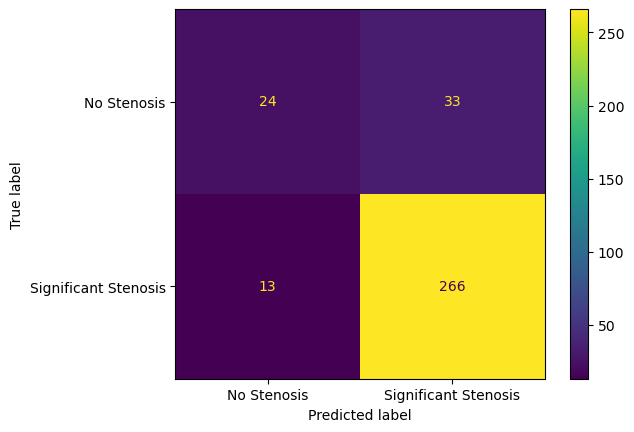

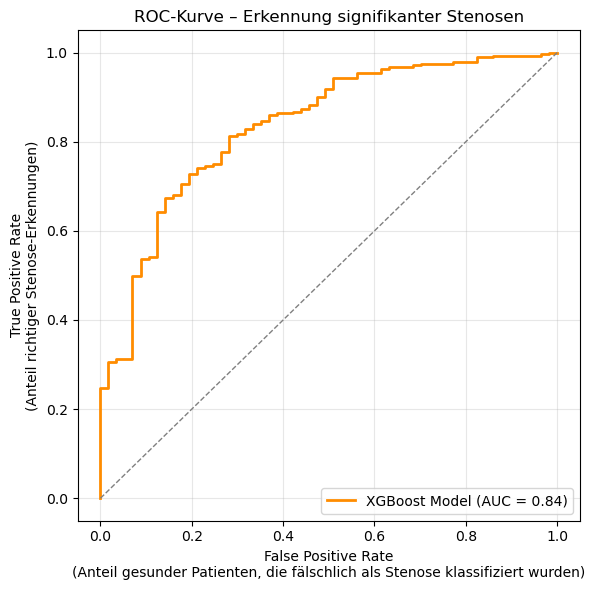

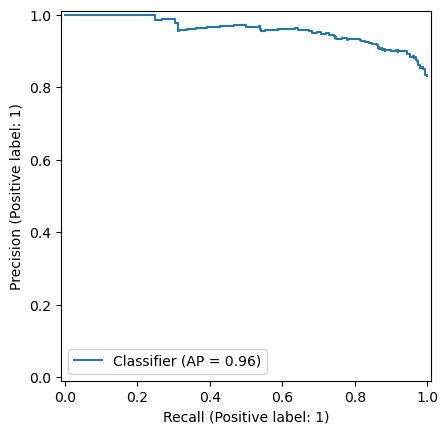

In [60]:

# Get preprocessed test data
X_test_prepared = pipeline.named_steps["preprocessor"].transform(X_test)
y_pred = pipeline.named_steps["classifier"].predict(X_test_prepared)

# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["No Stenosis", "Significant Stenosis"])

# ROC Curve
y_prob = pipeline.named_steps["classifier"].predict_proba(X_test_prepared)[:, 1]

# Calculate ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"XGBoost Model (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--")

# Achsenbeschriftungen und Titel
plt.xlabel("False Positive Rate\n(Anteil gesunder Patienten, die fälschlich als Stenose klassifiziert wurden)")
plt.ylabel("True Positive Rate\n(Anteil richtiger Stenose-Erkennungen)")
plt.title("ROC-Kurve – Erkennung signifikanter Stenosen")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Precision–Recall Curve
PrecisionRecallDisplay.from_predictions(y_test, pipeline.named_steps["classifier"].predict_proba(X_test_prepared)[:, 1])


## Visualization Multiclass

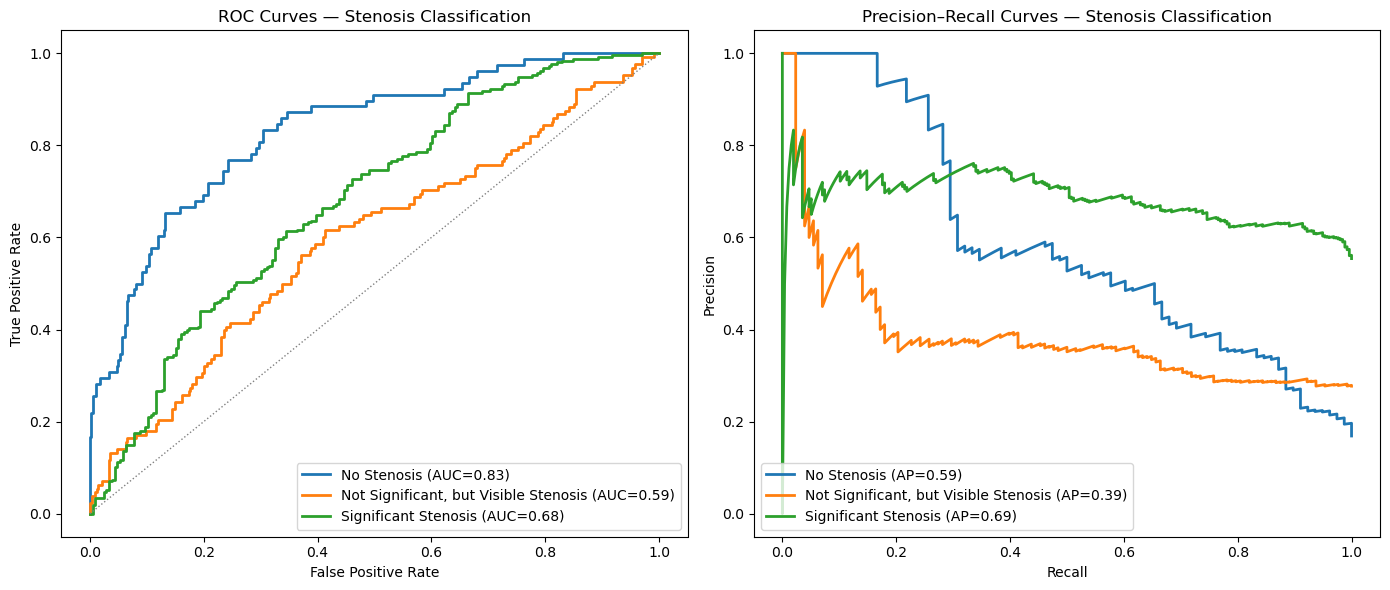

In [44]:
# Multiclass: ROC & PR curves side-by-side with class names (no micro-average) ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# Prepare test data and model
X_test_prepared = pipeline.named_steps["preprocessor"].transform(X_test)
clf = pipeline.named_steps["classifier"]
y_proba = clf.predict_proba(X_test_prepared)
y_pred = clf.predict(X_test_prepared)
classes = clf.classes_

# Define readable medical class names
class_names = {
    0: "No Stenosis",
    1: "Not Significant, but Visible Stenosis",
    2: "Significant Stenosis"
}

# Binarize labels for ROC/PR curves
Y_test_bin = label_binarize(y_test, classes=classes)

# Create a combined figure for ROC and PR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: ROC Curves 
ax = axes[0]
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{class_names[cls]} (AUC={roc_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle=":", lw=1, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Stenosis Classification")
ax.legend(loc="lower right")

# Right: Precision–Recall Curves
ax = axes[1]
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(Y_test_bin[:, i], y_proba[:, i])
    ax.plot(recall, precision, lw=2, label=f"{class_names[cls]} (AP={ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves — Stenosis Classification")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()


# Feature Importance

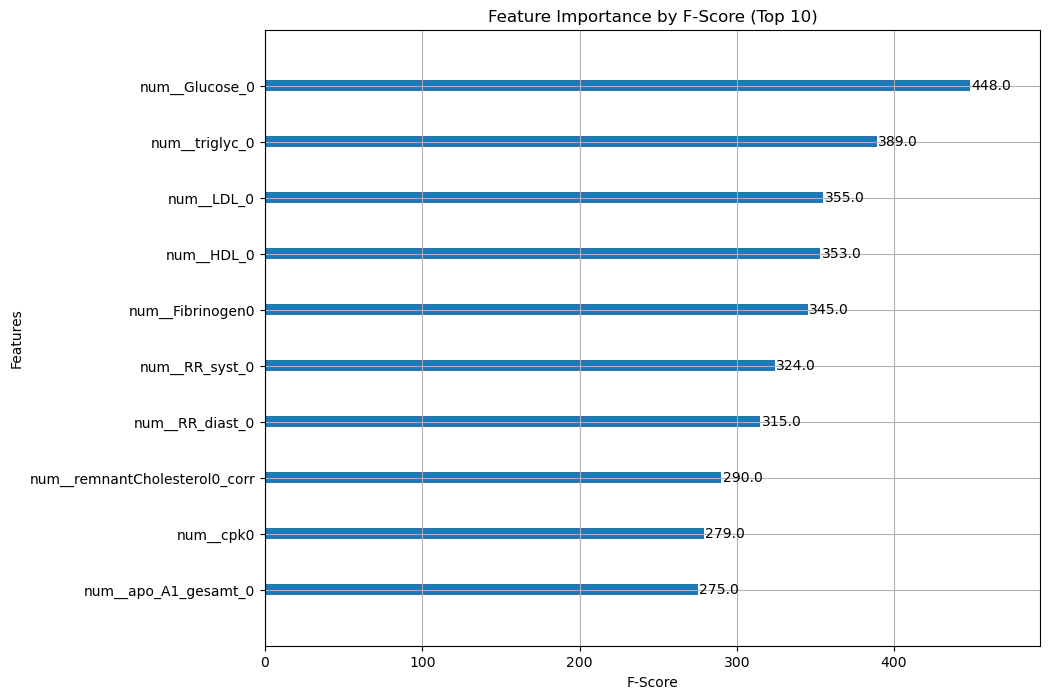

In [43]:
# Find the top 10 important features using XGBoost's plot_importance

# 1. Get the final feature names
feature_names_out = pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Extract the trained scikit-learn wrapper
xgb_model = pipeline.named_steps['classifier']

# 3. CRITICAL: Get the underlying Booster object
booster = xgb_model.get_booster()

# 4. CRITICAL: Set the feature names on the Booster object
booster.feature_names = list(feature_names_out)

# 5. Plot the importance using the Booster
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(
    booster,
    ax=ax,
    importance_type='weight',
    xlabel='F-Score',
    max_num_features=10
)
ax.set_title("Feature Importance by F-Score (Top 10)")
plt.show()

--- Worst 10 Features by F-Score Importance ---
                             Feature  Importance
0                    cat__Alter_0_41         1.0
67                cat__ldl0_mmol_nan         1.0
66   cat__ldl0_mmol_3,74967675200414         1.0
133                    cat__hct0_,38         1.0
63   cat__ldl0_mmol_2,22394621153349         1.0
145                    cat__hct0_nan         1.0
58                    cat__Lp_a_0_12         1.0
147                cat__CALCIUM_2,27         1.0
68   cat__hdl0_mmol_,801655029738816         1.0
55                      cat__WHR_0_1         1.0


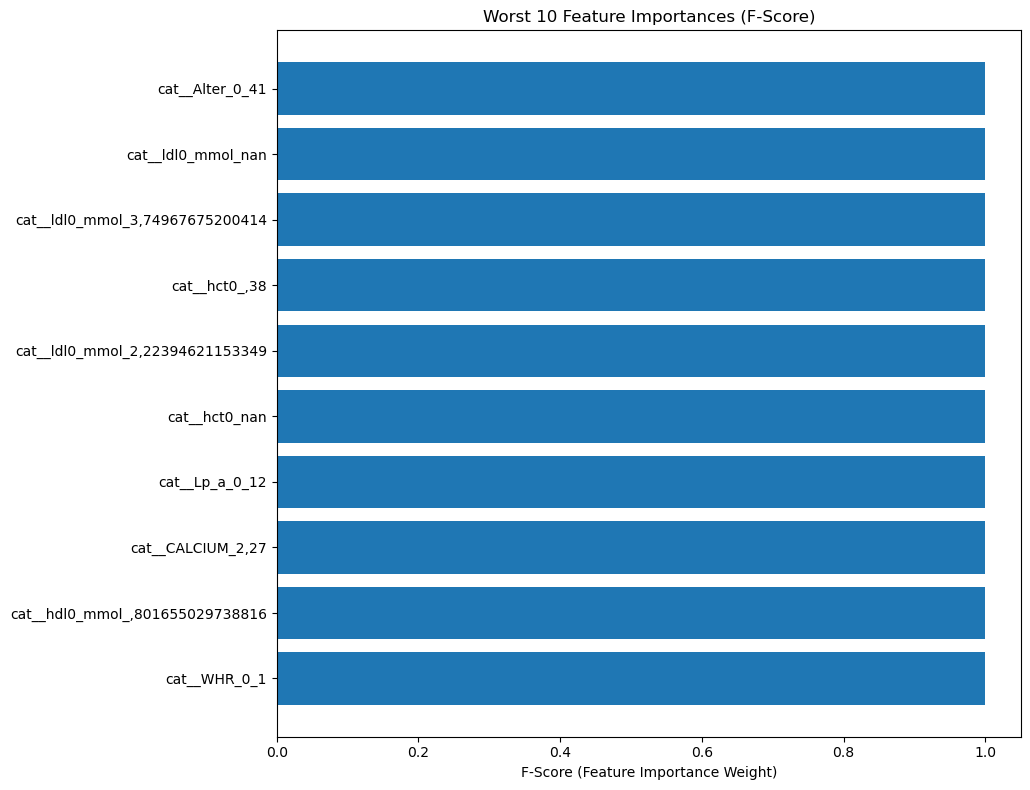

In [36]:
ig, (ax_top, ax_worst) = plt.subplots(1, 2, figsize=(18, 8)) 

# You must also define ax_top even if you don't plot on it, 
# or else you will get an index error later when you try to access ax_worst.
# Let's use a dummy plot on ax_top for now to keep the array structure intact.
ax_top.set_visible(False) # Hide the first axis if you only want to see the second one

# --- Your code snippet starts here ---
importance_dict = booster.get_score(importance_type='weight')
importance_df = pd.DataFrame(
    list(importance_dict.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=True)

worst_10_features = importance_df.head(10)

print("--- Worst 10 Features by F-Score Importance ---")
print(worst_10_features)

# Plot Worst 10 on the second subplot
ax_worst.barh(worst_10_features['Feature'], worst_10_features['Importance'])
ax_worst.set_title("Worst 10 Feature Importances (F-Score)")
ax_worst.set_xlabel("F-Score (Feature Importance Weight)")
ax_worst.invert_yaxis()

plt.tight_layout()
plt.show()